# Circuitos


## Leis de Kirchhoff

### Lei das malhas
Considere um circuito contendo elementos ativo e passivos. 
Tomamos um caminho fechado $C$ que toca no circuito apenas antes e depois de cada elemento.
A queda de tensão devido ao elemento $i$ do circuito é 
$$
\int_i^{i+1} \mathbf E \cdot d\mathbf l \equiv V_i \;.
$$
Pela lei de Faraday, devemos ter $\int_C \mathbf E \cdot d\mathbf l = 0$, pois consideramos que $\mathbf B = 0$ no espaço fora do circuito.
Assim a soma algébrica de todas as quedas de tensão ao longo de qualquer malha fechada deve ser zero:
$$
\sum_i V_i = 0 \;.
$$

### Lei dos nós
Considere agora um circuito composto por mais de uma malha. 
Um ponto comum a mais de uma malha é chamado de nó. 
Considere uma superfície gaussiana $S$ arbitrariamente pequena em torno de um nó qualquer do circuito.
O fluxo de $\mathbf j$ através de $S$ é simplesmente a soma algébrica de todas as correntes que passam pelo nó:
$$
\iint_S \mathbf j \cdot d\mathbf A = \sum_i I_i \;.
$$
Por outro lado, pelo teorema do divergente, o fluxo de $\mathbf j$ através de $S$ é igual à integral de div $\mathbf j$ sobre o volume delimitado por $S$. Mas, como o nó não é nem fonte nem sorvedouro de $\mathbf j$, temos que div $\mathbf j = 0$. Segue então que a soma algébrica das correntes em qualquer nó de um circuito é zero:
$$
\sum_i I_i = 0 \;.
$$

## Circuito RC

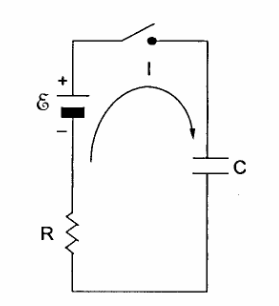

Considere uma malha de circuito contendo uma fonte de fem $\mathcal E$, uma chave, um capacitor de capacitância $C$, e um resistor de resistência $R$, como na imagem acima.

Utilizando as expressões apropriadas para as ddps de cada elemento do circuito, e utilizando a lei das malhas, obtemos
$$
RI + Q/C - \mathcal E = 0 \;,
$$

onde $Q$ é a carga no capacitor. 
Utilizando o fato de que $I = \dot Q$, podemos reescrever a eq. acima como
$$
\dot Q + Q/\tau = \mathcal E/R \;,
$$
onde $\tau \equiv RC$. 
Temos então uma EDO linear de primeira ordem não-homogênea de coeficientes constantes, cuja solução geral
é dada por $Q(t) = Q_h(t) + Q_p(t)$, onde $Q_h$ é a solução da EDO homogênea associada, e $Q_p$ é uma solução particular da EDO não-homogênea.

A EDO homogênea associada pode ser resolvida por separação de variáveis:
\begin{align*}
             \frac{dQ_h}{dt} + \frac{Q_h}{\tau} = 0 
    &\implies \frac{dQ_h}{q_h} = - \frac{dt}{\tau} \\[5pt]
    \implies \log{Q_h} &= -t/\tau + \log{Q_0} \\[5pt]
    \implies Q_h(t) &= Q_0 e^{-t/\tau} \;.
\end{align*}

Note que a EDO homogênea é obtida fazendo $\mathcal E = 0$ na não-homogênea, o que equivale ao circuito com a chave na posição aberta. A dinâmica obtida para $Q(t)$ então corresponde ao descarregamento do capacitor. O gráfico de $Q(t)$ é mostrado abaixo, onde definimos a carga inicial como sendo $Q_0 = 1$. 
Note que a escala de tempo é definida pela constante $\tau = RC$, que equivale ao tempo em que $Q(\tau) = Q_0/e$. 
Por esse motivo, a constante $\tau$ é chamada de constante de tempo.

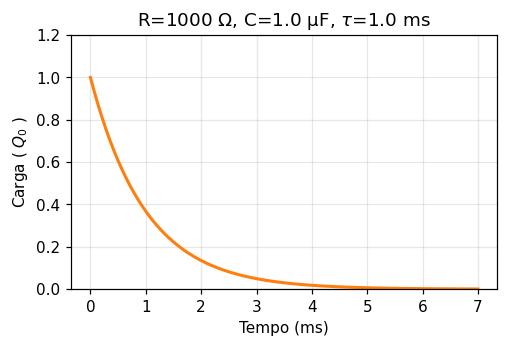

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3), dpi=110)
R, C = 1000, 1e-6
tau = R * C
T = np.linspace(0, 7*tau, 200)
Q = np.exp(-T/tau)
ax.plot(T*1e3, Q, linewidth=2, color='#ff7f0e')
ax.set_xlabel(r'Tempo (ms)')
ax.set_ylabel('Carga ( $Q_0$ )')
ax.set_ylim(0,1.2)
ax.set_title(rf'R={R} Ω, C={C*1e6} µF, $\tau$={tau*1e3} ms')
ax.grid(True, alpha=0.3)

Agora, para uma solução particular $Q_p$, vamos supor que $Q_p =$ constante, e portanto $\dot Q_p = 0$. Da EDO original, temos então 
$$
Q_p/\tau = \mathcal E / R \implies Q_p(t) = \mathcal E C \;.
$$

A solução geral é então
$$
Q(t) = A e^{-t/\tau} + \mathcal EC \;,
$$
onde $A$ é uma constante dada pelas condições iniciais. 

O caso $\mathcal E = 0$ foi considerado anteriormente. Fazendo agora $\mathcal E \neq 0$, $Q(t)$ representa o capacitor sendo carregado pela fonte. 
Considerando então que o capacitor se encontra completamente descarregado em $t=0$, temos que
\begin{align*}
    0 = Q(0) = A + \mathcal E C \implies A = -\mathcal E C \;.
\end{align*}

Substituindo esse $A$ na solução geral, encontramos
$$
Q(t) = \mathcal E C (1-e^{-t/\tau}) \;.
$$

Essa função é monotonicamente crescente, e , analisando seu comportamento assintótico, encontramos que $Q(t) \to \mathcal E C$ quando $t \to \infty$. 
Assim, a quantidade $Q_\infty \equiv \mathcal E C$ é a carga máxima do capacitor. 
O gráfico de $Q(t)$ é mostrado abaixo, onde definimos $Q_\infty = 1$.
Nesse caso, $\tau$ equivale ao valor de $t$ em que $Q(\tau) = Q_\infty(1-1/e)$.

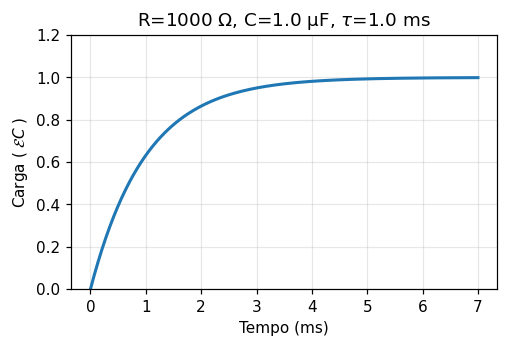

In [2]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=110)
R, C = 1000, 1e-6
tau = R * C
T = np.linspace(0, 7*tau, 200)
Q = 1 - np.exp(-T/tau)
ax.plot(T*1e3, Q, linewidth=2)
ax.set_xlabel('Tempo (ms)')
ax.set_ylabel(r'Carga ( $\mathcal{E}C$ )')
ax.set_ylim(0,1.2)
ax.set_title(rf'R={R} Ω, C={C*1e6} µF, $\tau$={tau*1e3} ms')
ax.grid(True, alpha=0.3)

## Circuito RL

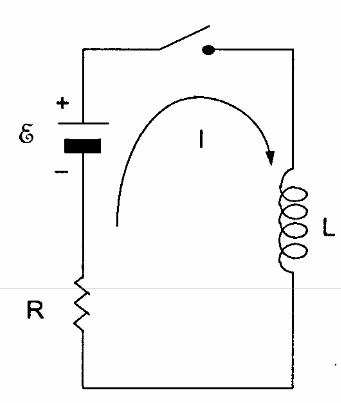

Considere agora que, no lugar do capacitor, há um indutor de indutância $L$. 
A lei das malhas resulta então em 
\begin{align*}
L \dot I + RI - \mathcal E = 0 \\
\implies \dot I + I/\tau = \mathcal E/ L \;,
\end{align*}

onde $\tau = L/R$ é a nova constante de tempo.
Temos então novamente uma EDO linear de primeira ordem não-homogênea de coeficientes constantes, mas com $I(t)$ no lugar de $Q(t)$. 
Analogamente ao caso do circuito RC, encontramos que a solução da EDO homogênea associada (tomando $\mathcal E = 0$) é da forma $I_h(t) = B \exp(-t/\tau)$, e uma solução particular é $I_p(t) = \mathcal E/R$.
A solução geral é então 
$$
I(t) = B e^{-t/\tau} + \mathcal E/R \;.
$$

Também supondo que $I(0) = 0$, a equação assume a forma 
$$
I(t) = \frac{\mathcal E}{R}(1 - e^{-t/\tau}) \;,
$$
que se comporta exatamente como $Q(t)$ da sessão anterior, como pode ser visto no gráfico abaixo. O valor assintótico é $I_\infty \equiv \mathcal E/R$, e $\tau$ novamente equivale ao valor de $t$ em que $I(\tau) = I_\infty(1-1/e)$.

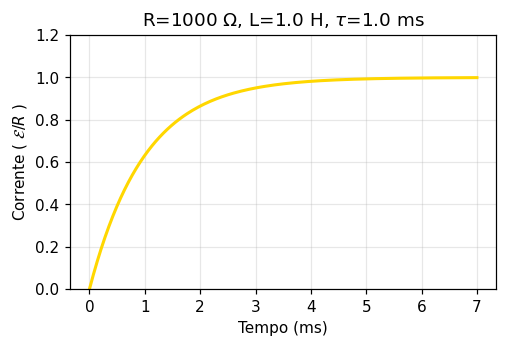

In [3]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=110)
R, L = 1000, 1
tau = L / R
T = np.linspace(0, 7*tau, 200)
I = 1 - np.exp(-T/tau)
ax.plot(T*1e3, I, linewidth=2, color='gold')
ax.set_xlabel('Tempo (ms)')
ax.set_ylabel(r'Corrente ( $\mathcal{E}/R$ )')
ax.set_ylim(0,1.2)
ax.set_title(rf'R={R} Ω, L={C*1e6} H, $\tau$={tau*1e3} ms')
ax.grid(True, alpha=0.3)

## Circuito LC

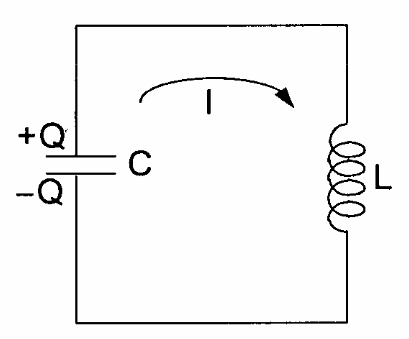

Considere agora uma malha com um indutor de indutância $L$ e um capacitor de capacitância $C$.
A lei das malhas resulta em 
$$
L \dot I + Q/C = 0 \;.
$$

Derivando no tempo e usando $I = \dot Q$, obtemos
$$
\ddot I + \omega_0^2 I = 0 \;,
$$
onde $\omega_0 \equiv (LC)^{-1/2}$. 
Obtemos então uma EDO linear de segunda ordem homogênea de coeficientes constantes. 
As raízes do polinômio característico são $\pm i \omega_0$. 
A solução geral da EDO é então
$$
I(t) = A e^{i\omega_0 t} + B e^{-i\omega_0 t} \;,
$$
onde $A$ e $B$ são constantes a serem determinadas. 
Integrando a equação acima no tempo, obtemos a função para a carga no capacitor:
$$
Q(t) = \frac{A e^{i\omega_0 t}}{i\omega_0} - \frac{B e^{-i\omega_0 t}}{i \omega_0} \;,
$$
sem constantes adicionais, pois a EDO é de segunda ordem e já temos duas constantes.

Se, no tempo $t=0$, a carga no capacitor é $Q_0$, e a corrente no circuito é $I_0$, temos as seguintes relações:
\begin{align*}
    A + B = I_0 \;, \qquad 
    A - B = i \omega_0 Q_0 \;.  
\end{align*}

Resolvendo para $A$ e $B$, obtemos 
\begin{align*}
    A = (I_0 + i \omega_0 Q_0)/2 \;, \qquad
    B = (I_0 - i \omega_0 Q_0)/2 \;.
\end{align*}

Substituindo essas expressões nas funções $I$ e $Q$, vemos que $I(t)$ é a soma de $A \exp(i \omega_0 t)$ com seu próprio conjugado complexo, assim como $Q(t)$ é para $A (i \omega_0)^{-1} \exp(i \omega_0 t)$.
Temos então
\begin{align*}
    I(t) &= 2 \text{ Re} \left[ (I_0 + i \omega_0 Q_0) e^{i \omega_0 t} /2\right] 
    = I_0\text{ Re}[e^{i \omega_0 t}] + \omega_0 Q_0 \text{ Re}[i  e^{i \omega_0 t}] \\[5pt]
    &= I_0 \cos(\omega_0 t) - \omega_0 Q_0 \sin(\omega_0 t) 
    = C \cos(\omega_0 t + \phi)
\end{align*}

onde utilizamos a relação de Euler $e^{ix} = \cos{x} + i\sin{x}$, e definimos duas novas constantes, $C$ e $\phi$, que seguem as relações
$$
C \cos\phi = I_0 \;, \qquad C \sin\phi = \omega_0 Q_0 \;.
$$

Resolvendo para $C$ e $\phi$, encontramos os valores desses parâmetros em função das condições iniciais:
$$
C = \sqrt{I_0^2 + \omega_0^2 Q_0^2} \;, \qquad \phi = \arctan{\frac{\omega_0 Q_0}{I_0}} \;.
$$

Integrando a nova expressão para $I(t)$ em $t$, obtemos a nova expressão para $Q(t)$:
$$
Q(t) = \frac{C}{\omega_0} \sin(\omega_0 t + \phi) \;.
$$

Assim, se a corrente inicial for zero e toda a carga estiver concentrada no capacitor, teremos que
$C = \omega_0 Q_0$, e $\phi = \arctan(\infty) = \pi / 2$.
Os gráficos de $I(t)$ e $Q(t)$ são mostrados abaixo para essas condições iniciais, onde $Q_0 = 1 \,\mu\text{C}$.

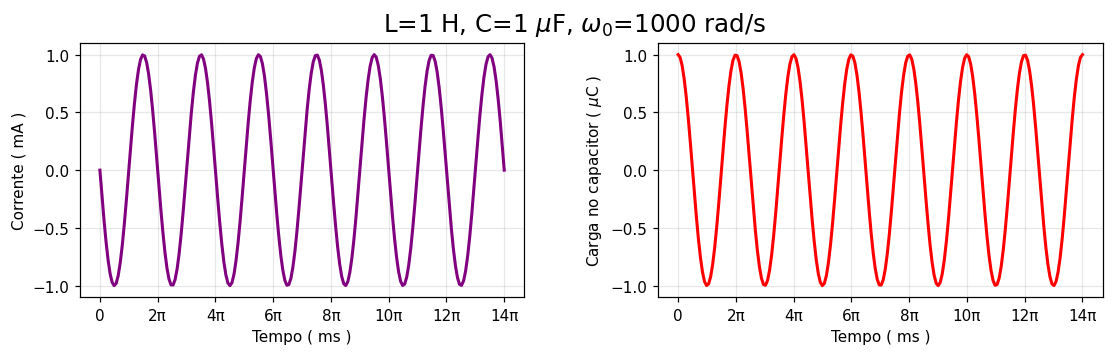

In [4]:
import matplotlib.ticker as ticker
fig, axes = plt.subplots(1, 2, figsize=(12, 3), dpi=110)

L, C = 1, 1e-6
omega = pow(L*C, -0.5)
period = 2*(np.pi)/omega
I0 = 0
Q0 = 1e-6
A = np.sqrt(I0**2 + (omega**2)*(Q0**2))
phi = np.arctan2(omega*Q0, I0)
T = np.linspace(0, 7*period, 200)
I = A * np.cos(omega*T + phi)
Q = (A/omega) * np.sin(omega*T + phi)

ax = axes[0]
ax.plot(T*1e3, I*1e3, linewidth=2, color='purple')
ax.set_xlabel('Tempo ( ms )')
ax.set_ylabel(r'Corrente ( mA )')
ax.xaxis.set_major_locator(ticker.MultipleLocator(2*np.pi))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, p: f'{int(round(x/(np.pi)))}π' if x != 0 else '0'
))
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(T*1e3, Q*1e6, linewidth=2, color='red')
ax.set_xlabel('Tempo ( ms )')
ax.set_ylabel(r'Carga no capacitor ( $\mu$C )')
ax.xaxis.set_major_locator(ticker.MultipleLocator(2*np.pi))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, p: f'{int(round(x/(np.pi)))}π' if x != 0 else '0'
))
ax.grid(True, alpha=0.3)

fig.suptitle(rf'L={L:.0f} H, C={C*1e6:.0f} $\mu$F, $\omega_0$={omega:.0f} rad/s', fontsize=16)
fig.subplots_adjust(wspace=0.3)